In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_excel("QVI_transaction_data.xlsx")
cust = pd.read_csv("QVI_purchase_behaviour.csv")

In [2]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


In [4]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


After the data import was successful, we can confirm that we have transaction-level data and customer segmentation data. This means that we can not only analyze "how much was sold," but also "who bought it," providing a foundation for customer segmentation analysis.The absence of missing values ​​indicates high data quality, allowing for direct entry into the analysis phase. While the field types are appropriate, the dates are in integer format, suggesting the original data originated from an Excel system and requires conversion before use for time-based analysis.

In [3]:
cust.head()
cust.info()
cust.describe()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


The datasets were initially explored using head(), info(), and describe() to understand their structure, variable types, and overall completeness. The transaction dataset contains a large number of records and includes both numeric and text fields, while the customer dataset represents customer-level segmentation information. At this stage, no missing values were observed in either dataset, indicating good structural quality. However, the DATE field in the transaction data was stored as an integer rather than a standard datetime format, which required conversion before any time-based analysis could be performed.

In [4]:
df["DATE"] = pd.to_datetime(df["DATE"], origin="1899-12-30", unit="D")
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


After conversion, the data was found to cover a full year (July 2018 to June 2019), indicating that the data has a complete periodicity and can support seasonal analysis (such as the impact of holidays).

In [9]:
df["PROD_NAME"].head(20)


0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
5     Old El Paso Salsa   Dip Tomato Mild 300g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
11       Kettle Sensations   Siracha Lime 150g
12                    Twisties Cheese     270g
13            WW Crinkle Cut      Chicken 175g
14              Thins Chips Light&  Tangy 175g
15                           CCs Original 175g
16                           Burger Rings 220g
17      NCC Sour Cream &    Garden Chives 175g
18     Doritos Corn Chip Southern Chicken 150g
19                    Cheezels Cheese Box 125g
Name: PROD_NAME, dtype: str

In [10]:
df["PROD_NAME"].nunique()

114

By examining the product names, it was discovered that the data included not only the brand, but also information such as flavor and packaging.

In [13]:
words = (
    df["PROD_NAME"]
    .drop_duplicates()      
    .str.split()            
    .explode()              
    .str.lower()            
)
words = words[~words.str.contains(r"\d", na=False)]  
words = words[words.str.isalpha()]     
print(words.value_counts().head(30)) 

df = df[~df["PROD_NAME"].str.lower().str.contains("salsa", na=False)]

PROD_NAME
chips         21
smiths        15
crinkle       13
cut           13
kettle        13
cheese        12
salt          12
original      10
chip           9
corn           8
pringles       8
rrd            8
chicken        7
doritos        7
ww             7
sour           6
sea            6
thinly         5
vinegar        5
chilli         5
thins          5
crisps         5
natural        4
cream          4
supreme        4
infuzions      4
ccs            3
tortilla       3
sweet          3
sensations     3
Name: count, dtype: int64


Salsa (not chips) was found to exist. The original data contained category contamination; analysis is more accurate after cleaning.

In [15]:


df.isnull().sum()


DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [16]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


The values ​​of PROD_QTY max = 200 and TOT_SALES max = 650 are significantly outside the normal range. Extreme purchasing behavior exists in the data, requiring further analysis; otherwise, it will affect the analysis of averages and total volumes.

In [17]:
outlier_txn = df[df["PROD_QTY"] == 200]
print(outlier_txn)

outlier_customer = outlier_txn["LYLTY_CARD_NBR"].unique()
print(df[df["LYLTY_CARD_NBR"].isin(outlier_customer)].sort_values(["LYLTY_CARD_NBR", "DATE"]))

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [18]:
df = df[~df["LYLTY_CARD_NBR"].isin(outlier_customer)]
print(df["PROD_QTY"].describe())

count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64


The abnormal transactions (200 packages) were identified, confirming that the anomaly was concentrated in a very small number of records. The anomaly was not a systemic issue, but rather an isolated transaction. It was discovered that this customer had very few transactions, but each purchase was in extremely large quantities. This is a bulk-buying customer (not a typical consumer), and does not represent typical purchasing behavior.

In [19]:
transactions_by_day = df.groupby("DATE").size().reset_index(name="N")
print(transactions_by_day.head())
print(transactions_by_day.shape)

        DATE    N
0 2018-07-01  663
1 2018-07-02  650
2 2018-07-03  674
3 2018-07-04  669
4 2018-07-05  660
(364, 2)


Daily transaction volume remains stable between 600 and 700. The data is stable with no significant fluctuations, indicating that overall business is operating normally.

In [20]:
full_dates = pd.DataFrame({
    "DATE": pd.date_range(start="2018-07-01", end="2019-06-30", freq="D")
})
transactions_by_day = full_dates.merge(transactions_by_day, on="DATE", how="left")
transactions_by_day["N"] = transactions_by_day["N"].fillna(0)

177   2018-12-25
Name: DATE, dtype: datetime64[us]


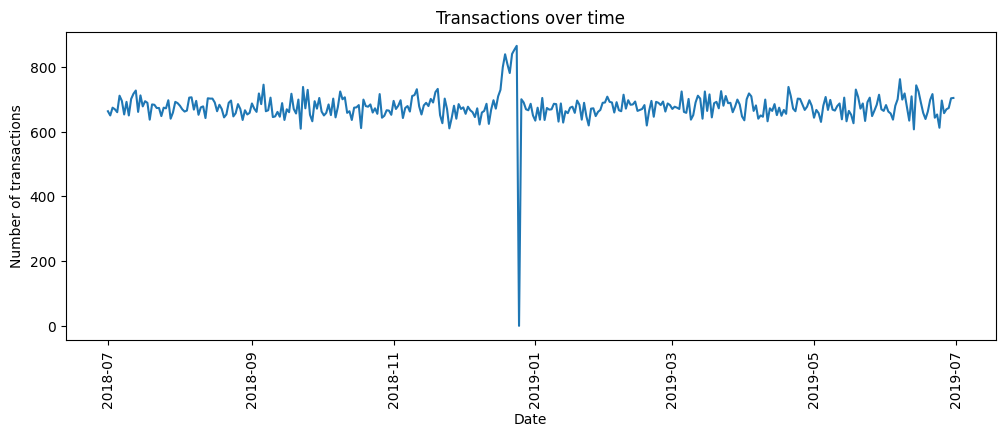

In [21]:
zero_days = transactions_by_day[transactions_by_day["N"] == 0]
print(zero_days["DATE"])

plt.figure(figsize=(12, 4))
plt.plot(transactions_by_day["DATE"], transactions_by_day["N"])
plt.title("Transactions over time")
plt.xlabel("Date")
plt.ylabel("Number of transactions")
plt.xticks(rotation=90)
plt.show()

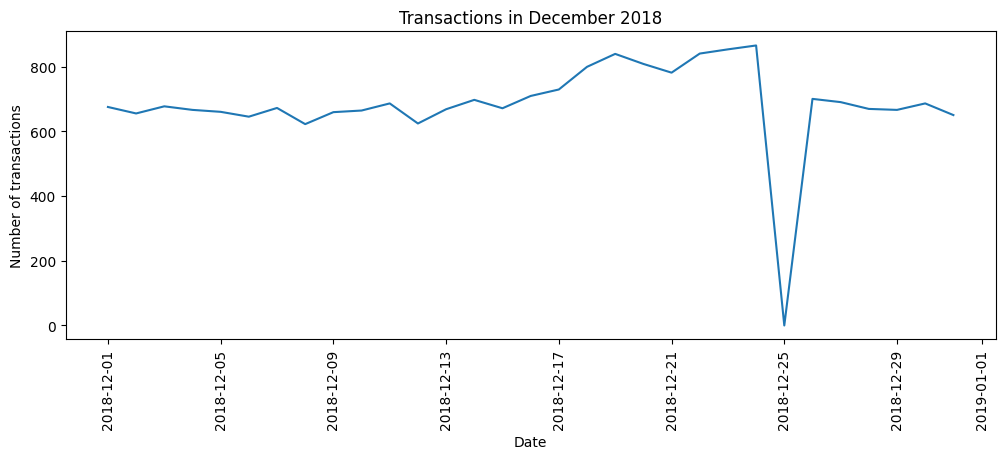

In [22]:
dec_data = transactions_by_day[
    (transactions_by_day["DATE"] >= "2018-12-01") &
    (transactions_by_day["DATE"] <= "2018-12-31")
]

plt.figure(figsize=(12, 4))
plt.plot(dec_data["DATE"], dec_data["N"])
plt.title("Transactions in December 2018")
plt.xlabel("Date")
plt.ylabel("Number of transactions")
plt.xticks(rotation=90)
plt.show()

One day was found to be missing. Upon inspection, it was determined to be Christmas Day (no transactions). The missing day was not a data error, but rather a reflection of the actual business situation (stores were closed).
The overall transaction volume remains stable throughout the year, averaging around 650–750 transactions per day. A sharp drop to zero is observed on a specific date, which corresponds to Christmas Day when stores were closed. This indicates a valid business pattern rather than a data issue.
A clear seasonal pattern is observed in December. Transaction volumes increase steadily leading up to Christmas, suggesting that customers stock up on chips for holiday gatherings. On Christmas Day, transactions drop to zero due to store closures, before returning to normal levels afterward. This confirms that chips are strongly associated with festive consumption behaviour.
Chip purchases are generally stable throughout the year, but show strong seasonal spikes during festive periods, particularly Christmas, indicating their role as a social and sharing product.

In [23]:
df["PACK_SIZE"] = df["PROD_NAME"].str.extract(r"(\d+)").astype(float)
df["PACK_SIZE"].value_counts().sort_index()

PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    40203
160.0     2970
165.0    15297
170.0    19983
175.0    66390
180.0     1468
190.0     2995
200.0     4473
210.0     6272
220.0     1564
250.0     3169
270.0     6285
330.0    12540
380.0     6416
Name: count, dtype: int64

Packaging size was successfully extracted (the range of 70g–380g is reasonable). Packaging size is a valid variable and can be used to analyze consumer preferences (large packaging vs. small packaging).

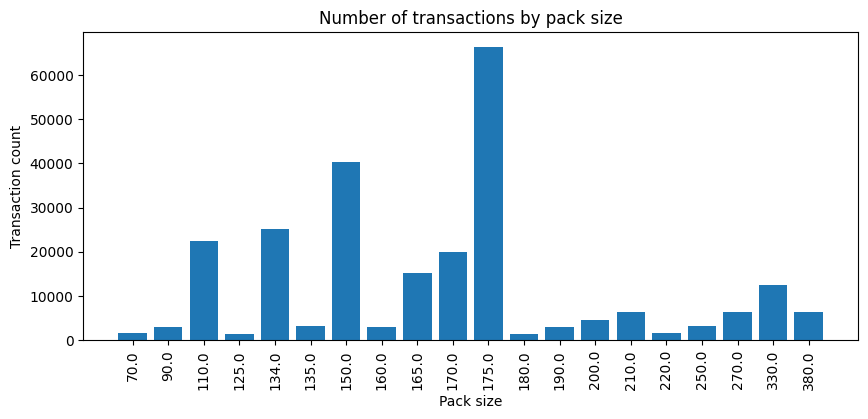

In [24]:
pack_counts = df["PACK_SIZE"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(pack_counts.index.astype(str), pack_counts.values)
plt.title("Number of transactions by pack size")
plt.xlabel("Pack size")
plt.ylabel("Transaction count")
plt.xticks(rotation=90)
plt.show()

The distribution of pack sizes shows a strong concentration around medium-sized products, particularly 175g packs, which dominate transaction counts. Smaller pack sizes (below 100g) and larger packs (above 200g) are significantly less popular. This suggests that customers prefer medium-sized packs, likely due to their suitability for sharing and perceived value for money.

In [25]:
df["BRAND"] = df["PROD_NAME"].str.split().str[0].str.upper()
print(df["BRAND"].value_counts())

BRAND
KETTLE        41288
SMITHS        27390
PRINGLES      25102
DORITOS       22041
THINS         14075
RRD           11894
INFUZIONS     11057
WW            10320
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
RED            4427
DORITO         3183
INFZNS         3144
SMITH          2963
CHEETOS        2927
SNBTS          1576
BURGER         1564
WOOLWORTHS     1516
GRNWVES        1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64


In [26]:
df["BRAND"] = df["BRAND"].replace({
    "RED": "RRD",
    "SNBTS": "SUNBITES",
    "INFZNS": "INFUZIONS",
    "WW": "WOOLWORTHS",
    "SMITH": "SMITHS"
})
print(df["BRAND"].value_counts())

BRAND
KETTLE        41288
SMITHS        30353
PRINGLES      25102
DORITOS       22041
RRD           16321
INFUZIONS     14201
THINS         14075
WOOLWORTHS    11836
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
DORITO         3183
SUNBITES       3008
CHEETOS        2927
BURGER         1564
GRNWVES        1468
NCC            1419
FRENCH         1418
Name: count, dtype: int64


Brands were successfully extracted and given a unified name. This enables brand analysis, which can be used for subsequent preference analysis.

In [27]:
data = df.merge(cust, on="LYLTY_CARD_NBR", how="left")
print(data.shape)
print(data[["LIFESTAGE", "PREMIUM_CUSTOMER"]].isnull().sum())

(246740, 12)
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


The final analysis table was generated, confirming that no data was lost during merging.

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6           OLDER FAMILIES           Budget  156863.75
19   YOUNG SINGLES/COUPLES       Mainstream  147582.20
13                RETIREES       Mainstream  145168.95
15          YOUNG FAMILIES           Budget  129717.95
9    OLDER SINGLES/COUPLES           Budget  127833.60
10   OLDER SINGLES/COUPLES       Mainstream  124648.50
11   OLDER SINGLES/COUPLES          Premium  123537.55
12                RETIREES           Budget  105916.30
7           OLDER FAMILIES       Mainstream   96413.55
14                RETIREES          Premium   91296.65
16          YOUNG FAMILIES       Mainstream   86338.25
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25
17          YOUNG FAMILIES          Premium   78571.70
8           OLDER FAMILIES          Premium   75242.60
18   YOUNG SINGLES/COUPLES           Budget   57122.10
2   MIDAGE SINGLES/COUPLES          Premium   54443.85
20   YOUNG SINGLES/COUPLES          Premium   39052.30
0   MIDAGE

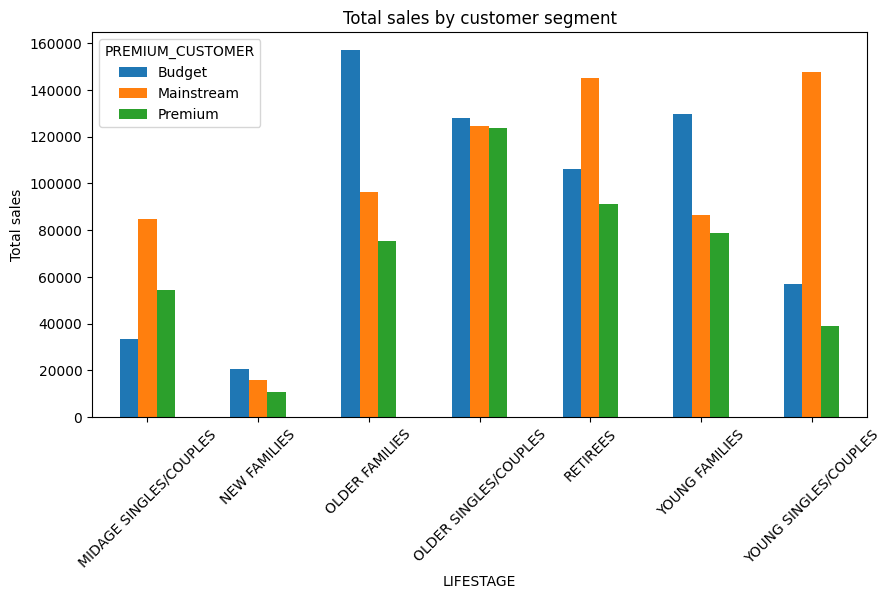

In [28]:
sales_seg = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .reset_index()
)
print(sales_seg.sort_values("TOT_SALES", ascending=False))

pivot_sales = sales_seg.pivot(index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="TOT_SALES")
pivot_sales.plot(kind="bar", figsize=(10, 5))
plt.title("Total sales by customer segment")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.show()

The analysis reveals that chip sales are highly concentrated among specific customer segments, particularly Budget older families, Mainstream young singles/couples, and Mainstream retirees. Older families contribute significantly due to higher purchase volumes, while young singles/couples drive sales through frequent purchases and brand preferences. Retirees exhibit stable and consistent consumption patterns across pricing tiers. These findings suggest that marketing strategies should be tailored to different behavioural drivers, focusing on value-based promotions for families and brand-driven engagement for younger consumers.

In [29]:
cust_count = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="CUSTOMER_COUNT")
)

print(cust_count.sort_values("CUSTOMER_COUNT", ascending=False))

                 LIFESTAGE PREMIUM_CUSTOMER  CUSTOMER_COUNT
19   YOUNG SINGLES/COUPLES       Mainstream            7917
13                RETIREES       Mainstream            6358
10   OLDER SINGLES/COUPLES       Mainstream            4858
9    OLDER SINGLES/COUPLES           Budget            4849
11   OLDER SINGLES/COUPLES          Premium            4682
6           OLDER FAMILIES           Budget            4611
12                RETIREES           Budget            4385
15          YOUNG FAMILIES           Budget            3953
14                RETIREES          Premium            3812
18   YOUNG SINGLES/COUPLES           Budget            3647
1   MIDAGE SINGLES/COUPLES       Mainstream            3298
7           OLDER FAMILIES       Mainstream            2788
16          YOUNG FAMILIES       Mainstream            2685
20   YOUNG SINGLES/COUPLES          Premium            2480
17          YOUNG FAMILIES          Premium            2398
2   MIDAGE SINGLES/COUPLES          Prem

The analysis of customer counts shows that Mainstream young singles/couples represent the largest customer group, indicating that high sales in this segment are largely driven by customer volume. In contrast, Budget older families generate the highest total sales despite having fewer customers, suggesting that their purchasing behaviour is driven by higher volume per customer. This highlights that different segments contribute to sales in fundamentally different ways.
While young singles/couples contribute significantly due to their large customer base, older families drive the highest sales through higher purchase quantities per customer.

In [30]:
units_per_customer = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(total_units=("PROD_QTY", "sum"),
         customer_count=("LYLTY_CARD_NBR", "nunique"))
    .reset_index()
)

units_per_customer["avg_units_per_customer"] = (
    units_per_customer["total_units"] / units_per_customer["customer_count"]
)

print(units_per_customer.sort_values("avg_units_per_customer", ascending=False))

                 LIFESTAGE PREMIUM_CUSTOMER  total_units  customer_count  \
7           OLDER FAMILIES       Mainstream        25804            2788   
6           OLDER FAMILIES           Budget        41853            4611   
8           OLDER FAMILIES          Premium        20239            2231   
15          YOUNG FAMILIES           Budget        34482            3953   
17          YOUNG FAMILIES          Premium        20901            2398   
16          YOUNG FAMILIES       Mainstream        23194            2685   
9    OLDER SINGLES/COUPLES           Budget        32883            4849   
11   OLDER SINGLES/COUPLES          Premium        31695            4682   
10   OLDER SINGLES/COUPLES       Mainstream        32607            4858   
1   MIDAGE SINGLES/COUPLES       Mainstream        21213            3298   
12                RETIREES           Budget        26932            4385   
14                RETIREES          Premium        23266            3812   
2   MIDAGE S

The analysis of average units per customer reveals that older families purchase significantly more chips per customer compared to other segments, with an average of over 9 units per customer. In contrast, young singles/couples purchase fewer units per customer but contribute strongly to total sales due to their larger population. This highlights that chip consumption is driven by both household size and purchase frequency, with families driving volume and younger consumers driving transaction frequency.Families drive volume, young singles drive frequency, and both are critical for total sales.

In [31]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]
price_seg = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PRICE_PER_UNIT"]
    .mean()
    .reset_index()
)

print(price_seg.sort_values("PRICE_PER_UNIT", ascending=False))

                 LIFESTAGE PREMIUM_CUSTOMER  PRICE_PER_UNIT
19   YOUNG SINGLES/COUPLES       Mainstream        4.065642
1   MIDAGE SINGLES/COUPLES       Mainstream        3.994241
12                RETIREES           Budget        3.924404
14                RETIREES          Premium        3.920942
3             NEW FAMILIES           Budget        3.917688
4             NEW FAMILIES       Mainstream        3.916133
11   OLDER SINGLES/COUPLES          Premium        3.893182
9    OLDER SINGLES/COUPLES           Budget        3.882096
5             NEW FAMILIES          Premium        3.872110
13                RETIREES       Mainstream        3.844294
10   OLDER SINGLES/COUPLES       Mainstream        3.814665
2   MIDAGE SINGLES/COUPLES          Premium        3.770698
17          YOUNG FAMILIES          Premium        3.762150
15          YOUNG FAMILIES           Budget        3.760737
6           OLDER FAMILIES           Budget        3.745340
0   MIDAGE SINGLES/COUPLES           Bud

The price per unit analysis shows that Mainstream young singles/couples pay the highest price per unit, indicating a stronger preference for branded or premium products. In contrast, family segments tend to purchase at lower unit prices, suggesting a focus on value and larger pack sizes. Combined with earlier findings, this highlights that different customer segments drive sales through different mechanisms: young singles through higher frequency and price sensitivity to brand, and older families through higher purchase volumes.Young singles drive revenue through price and frequency, while families drive it through volume.

In [32]:
group1 = data[
    (data["LIFESTAGE"].isin(["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"])) &
    (data["PREMIUM_CUSTOMER"] == "Mainstream")
]["PRICE_PER_UNIT"]

group2 = data[
    (data["LIFESTAGE"].isin(["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"])) &
    (data["PREMIUM_CUSTOMER"].isin(["Budget", "Premium"]))
]["PRICE_PER_UNIT"]

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(t_stat, p_val)

37.6243885962295 6.967354233017819e-306


A t-test was conducted to compare the average price per unit between Mainstream young and midage singles/couples and other segments. The results show a highly significant difference (p-value < 0.001), indicating that the higher price per unit observed in the Mainstream segment is statistically meaningful rather than due to random variation.

In [33]:
target = data[
    (data["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
    (data["PREMIUM_CUSTOMER"] == "Mainstream")
]

brand_pref = target["BRAND"].value_counts(normalize=True).reset_index()
brand_pref.columns = ["BRAND", "TARGET_PROP"]

overall_brand = data["BRAND"].value_counts(normalize=True).reset_index()
overall_brand.columns = ["BRAND", "OVERALL_PROP"]

brand_compare = brand_pref.merge(overall_brand, on="BRAND", how="left")
brand_compare["AFFINITY"] = brand_compare["TARGET_PROP"] / brand_compare["OVERALL_PROP"]

print(brand_compare.sort_values("AFFINITY", ascending=False))

         BRAND  TARGET_PROP  OVERALL_PROP  AFFINITY
10    TYRRELLS     0.031672      0.026108  1.213098
6     TWISTIES     0.046050      0.038316  1.201858
15      DORITO     0.015503      0.012900  1.201800
2      DORITOS     0.106222      0.089329  1.189110
7     TOSTITOS     0.045538      0.038385  1.186370
0       KETTLE     0.196684      0.167334  1.175400
1     PRINGLES     0.118451      0.101735  1.164310
11       GRAIN     0.029472      0.025419  1.159425
9         COBS     0.044208      0.039284  1.125335
4    INFUZIONS     0.063958      0.057555  1.111264
5        THINS     0.059660      0.057044  1.045867
13    CHEEZELS     0.017704      0.018655  0.948989
3       SMITHS     0.098291      0.123016  0.799009
17     CHEETOS     0.008494      0.011863  0.715997
19      FRENCH     0.003991      0.005747  0.694456
8          RRD     0.044771      0.066147  0.676842
14     NATURAL     0.016424      0.024520  0.669847
20         NCC     0.003735      0.005751  0.649481
16         C

The brand affinity analysis shows that Mainstream young singles/couples over-index on brands such as Doritos, Pringles, Kettle, and Twisties, indicating a strong preference for well-known and differentiated brands. In contrast, they under-index on more traditional or budget-oriented brands such as Smiths and Woolworths. This suggests that younger consumers are more brand-driven and willing to pay for perceived quality and variety.

In [34]:
pack_pref = target["PACK_SIZE"].value_counts(normalize=True).reset_index()
pack_pref.columns = ["PACK_SIZE", "TARGET_PROP"]

overall_pack = data["PACK_SIZE"].value_counts(normalize=True).reset_index()
overall_pack.columns = ["PACK_SIZE", "OVERALL_PROP"]

pack_compare = pack_pref.merge(overall_pack, on="PACK_SIZE", how="left")
pack_compare["AFFINITY"] = pack_compare["TARGET_PROP"] / pack_compare["OVERALL_PROP"]

print(pack_compare.sort_values("AFFINITY", ascending=False))

    PACK_SIZE  TARGET_PROP  OVERALL_PROP  AFFINITY
8       270.0     0.031723      0.025472  1.245410
7       380.0     0.032030      0.026003  1.231788
5       330.0     0.061144      0.050823  1.203085
2       134.0     0.118451      0.101735  1.164310
9       210.0     0.029472      0.025419  1.159425
3       110.0     0.104943      0.090731  1.156634
10      135.0     0.014838      0.013200  1.124104
11      250.0     0.014327      0.012843  1.115480
4       170.0     0.080587      0.080988  0.995052
1       150.0     0.157593      0.162937  0.967205
0       175.0     0.255679      0.269069  0.950239
6       165.0     0.056386      0.061996  0.909497
13      190.0     0.007573      0.012138  0.623866
16      180.0     0.003582      0.005950  0.602002
15      160.0     0.006549      0.012037  0.544101
14       90.0     0.006549      0.012191  0.537228
17       70.0     0.003223      0.006108  0.527781
19      125.0     0.003019      0.005893  0.512287
12      200.0     0.009159     

The pack size affinity analysis shows that Mainstream young singles/couples over-index on larger pack sizes such as 270g, 330g, and 380g, while under-indexing on the most common market pack sizes like 150g and 175g. This suggests that younger consumers are more likely to purchase larger packs, possibly for social consumption or perceived value. Combined with their strong brand preferences and higher price per unit, this indicates that this segment is driven more by experience and brand engagement than price sensitivity.

Key Insights
The analysis reveals that chip purchasing behaviour differs significantly across customer segments, with three key drivers identified: customer volume, purchase frequency, and value per transaction.

Firstly, Mainstream young singles/couples represent the largest customer group and contribute significantly to total sales. Their higher price per unit and strong brand affinity indicate that they are willing to pay for differentiated and branded products.

Secondly, Budget older families generate the highest total sales despite having fewer customers. This is driven by a higher number of units purchased per customer, suggesting bulk purchasing behaviour likely associated with larger household sizes.

Finally, retirees contribute steady and consistent sales across all pricing tiers, indicating stable demand rather than extreme purchasing behaviour.


Customer Behaviour Summary
Young singles/couples are frequency-driven and brand-sensitive, contributing through both high transaction frequency and higher price per unit.
Older families are volume-driven, purchasing significantly more units per customer.
Retirees are consistency-driven, contributing stable demand across the year.


Product Preferences
Brand affinity analysis shows that Mainstream young singles/couples over-index on brands such as Doritos, Pringles, Kettle, and Twisties, while under-indexing on traditional or budget-oriented brands such as Smiths and Woolworths.
Pack size analysis indicates that this segment prefers larger pack sizes (270g–380g) and under-indexes on the most common pack sizes (150g–175g), suggesting a preference for sharing or value-based purchases.


Strategic Recommendations
1.Focus marketing efforts on Mainstream young singles/couples by promoting premium and branded products. Emphasize new flavours, product innovation, and strong brand positioning to capture their willingness to pay.
2.Promote value-based offerings such as larger pack sizes and bundle deals to older families. Pricing strategies should emphasize cost efficiency and bulk purchasing incentives.
3.Adjust product assortment to align with segment preferences by increasing availability of larger pack sizes for younger consumers and maintaining mid-sized packs for family segments.

Final Conclusion    
Different customer segments drive chip sales through distinct mechanisms. Young singles/couples drive revenue through higher frequency and willingness to pay, while older families drive revenue through higher purchase volumes. A targeted strategy that aligns product offerings and marketing efforts with these behaviours will maximize overall sales performance. This data-driven segmentation approach enables more effective targeting and supports evidence-based decision making for category growth.